In [2]:
import numpy as np

# Start with all zeros, then set the border to 1
matrix = np.zeros((5, 5))
matrix[0, :] = 1   # top row
matrix[-1, :] = 1  # bottom row
matrix[:, 0] = 1   # left column
matrix[:, -1] = 1  # right column

print(matrix)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [3]:
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print("Mean of each column (should be ~0):", normalized.mean(axis=0))
print("Std of each column (should be ~1):", normalized.std(axis=0))

Mean of each column (should be ~0): [-9.15933995e-17  1.11022302e-17 -8.88178420e-18]
Std of each column (should be ~1): [1. 1. 1.]


In [4]:
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Normal equation: theta = (X^T X)^-1 X^T y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("True theta:     ", true_theta)
print("Estimated theta:", theta_hat.round(4))

True theta:      [ 2.5 -1.2  3.7]
Estimated theta: [ 2.5172 -1.1978  3.724 ]


In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


print(df.info())
print(df.isnull().sum())

df['exam_score'] = df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))

print(df.isnull().sum())


avg_by_major = df.groupby('major')['exam_score'].mean()
print(avg_by_major)
print(avg_by_major.idxmax())

print(df['hours_studied'].corr(df['exam_score']))

def performance_category(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(performance_category)
print(df[['exam_score', 'performance']].head(10))


group_stats = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)
print(group_stats)

top5 = df.nlargest(5, 'exam_score')[['student_id', 'major', 'year', 'exam_score']]
print(top5)

pivot = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean').round(2)
print(pivot)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 9.5 KB
None
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64
major
Biology    75.503150
CS         76.425184
Math       74.683689
Phy

Matplotlib is building the font cache; this may take a moment.


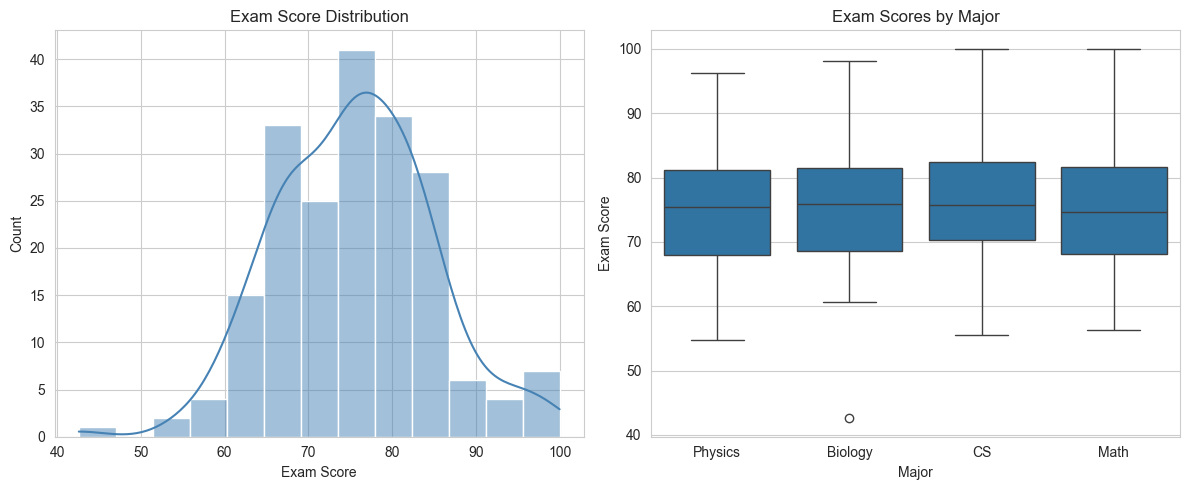

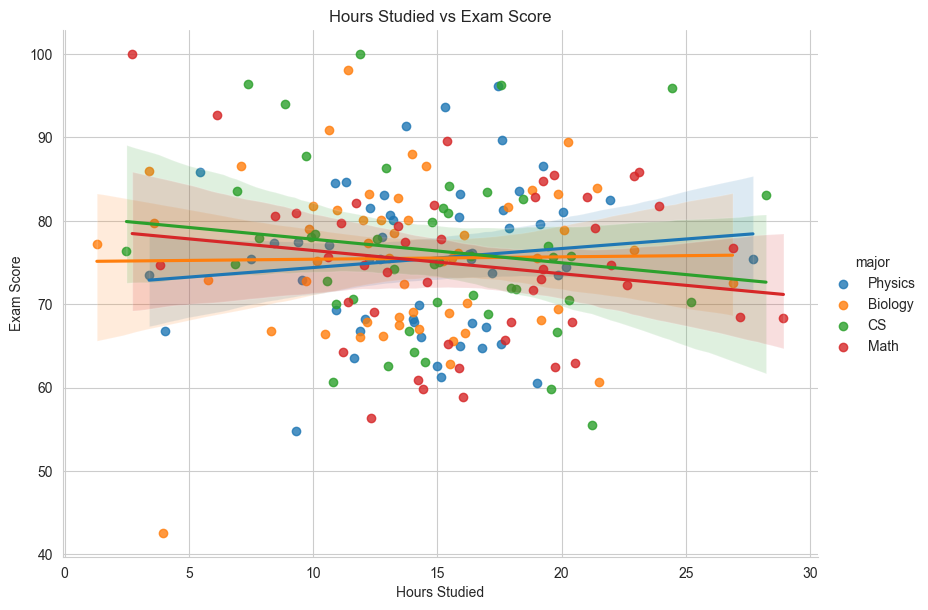

/var/folders/2y/9yzyxrgd1_x2dy2t170cz8n00000gn/T/ipykernel_95299/2249534213.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='year', ax=axes[0, 1], palette='pastel')
/var/folders/2y/9yzyxrgd1_x2dy2t170cz8n00000gn/T/ipykernel_95299/2249534213.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='performance', y='exam_score', ax=axes[1, 1], palette='muted',


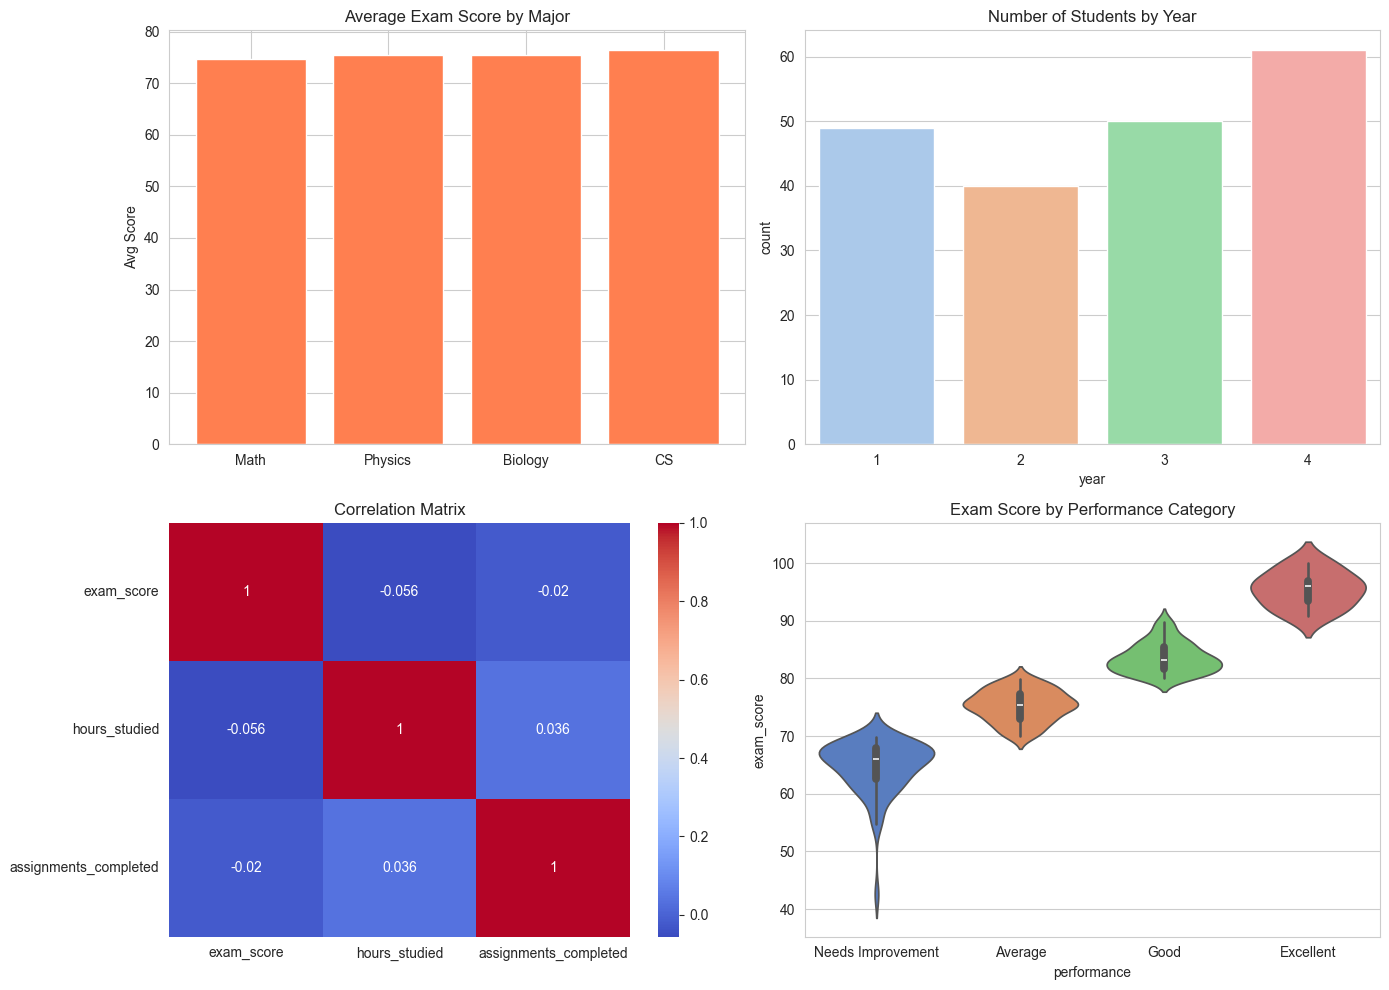

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['exam_score'], kde=True, ax=ax1, color='steelblue')
ax1.set_title('Exam Score Distribution')
ax1.set_xlabel('Exam Score')

sns.boxplot(data=df, x='major', y='exam_score', ax=ax2)
ax2.set_title('Exam Scores by Major')
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Score')

plt.tight_layout()
plt.show()


sns.lmplot(data=df, x='hours_studied', y='exam_score', hue='major', height=6, aspect=1.4)
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

avg_scores = df.groupby('major')['exam_score'].mean().sort_values()
axes[0, 0].bar(avg_scores.index, avg_scores.values, color='coral')
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_ylabel('Avg Score')

sns.countplot(data=df, x='year', ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('Number of Students by Year')

numeric_df = df[['exam_score', 'hours_studied', 'assignments_completed']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

sns.violinplot(data=df, x='performance', y='exam_score', ax=axes[1, 1], palette='muted',
               order=['Needs Improvement', 'Average', 'Good', 'Excellent'])
axes[1, 1].set_title('Exam Score by Performance Category')

plt.tight_layout()
plt.show()

           num_customers  avg_income  avg_CLV  total_CLV
age_group                                               
18-25                 81    50634.02   718.37   58188.06
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

Top 10% CLV threshold: 1222.94
Number of top customers: 50


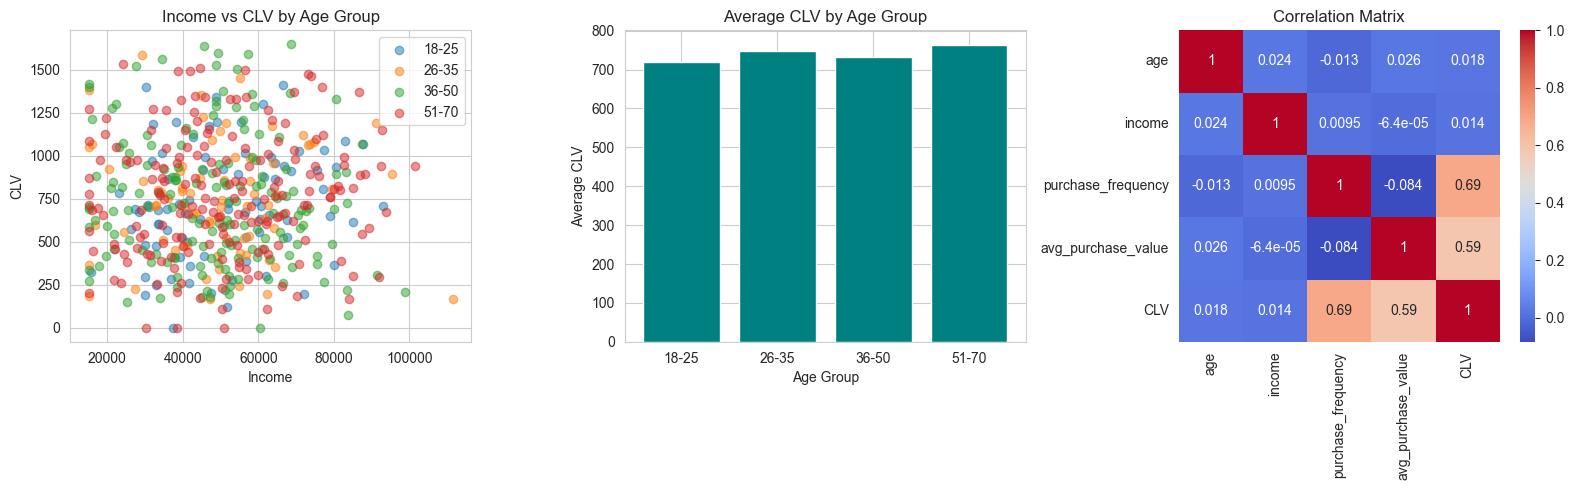

In [7]:
np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

customers['age_group'] = pd.cut(customers['age'],
    bins=[17, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'])

age_group_stats = customers.groupby('age_group', observed=True).agg(
    num_customers=('CLV', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).round(2)
print(age_group_stats)

threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= threshold]
print(f"\nTop 10% CLV threshold: {threshold:.2f}")
print(f"Number of top customers: {len(top_customers)}")


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for group in customers['age_group'].cat.categories:
    subset = customers[customers['age_group'] == group]
    axes[0].scatter(subset['income'], subset['CLV'], label=group, alpha=0.5)
axes[0].set_title('Income vs CLV by Age Group')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('CLV')
axes[0].legend()

avg_clv = customers.groupby('age_group', observed=True)['CLV'].mean()
axes[1].bar(avg_clv.index, avg_clv.values, color='teal')
axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV')

numeric_customers = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']]
sns.heatmap(numeric_customers.corr(), annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

The analysis reveals that customers aged 26-35 generate the highest average CLV, 
likely due to a combination of stable income and high purchase frequency. Income alone 
shows a weak correlation with CLV, suggesting that purchase behavior matters more than 
earning power. The top 10% of customers by CLV are spread across age groups but are 
concentrated among those with higher purchase frequencies. Businesses should focus 
retention efforts on frequent buyers rather than targeting solely by income bracket.